# Estado macroscópico del tablero: observables, información mutua y β estructural

El proyecto trabaja en tres niveles:

| Nivel | Objeto | Dónde vive |
|---|---|---|
| **Micro** | cada intersección $s_i \in \{-1, 0, +1\}$ (negro, vacío, blanco) | codificación spin-1 |
| **Meso** | mapas posicionales sobre vecindades Manhattan | `src/go_isings_models.py` |
| **Macro** | números que resumen todo el tablero, uno por jugada | `src/go_macro.py` (este cuaderno) |

Este cuaderno introduce y experimenta con el **vector macro** $X_t$: para cada jugada $t$ calculamos balance, ocupación, correlaciones por escala, información mutua y un $\beta$ estructural efectivo. El objetivo final es integrar estas series por jugada al motor de visualización (`GameNavigator`).

**Convención:** negro $=-1$, blanco $=+1$, vacío $=0$ — la del resto del proyecto.

**Advertencia de nombre:** nuestro $\beta$ estructural NO es la temperatura de la teoría combinatoria de juegos (Berlekamp) ni una temperatura termodinámica real — el tablero no es una muestra de equilibrio. Es un *descriptor de organización* ajustado por pseudoverosimilitud.


In [1]:
# Imports, partida de ejemplo y cálculo de la trayectoria macro
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / 'src').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import src.go_macro as gm
importlib.reload(gm)
from src.go_game_engine import GoBoard, SGFParser

SGF_FILE = '3a3d-gokifu-20210609-Peng_Liyao-Xia_Chenkun.sgf'
R_MAX = 6      # alcance de los perfiles C_occ / O / MI
BETA_R = 2     # alcance del Hamiltoniano estructural para betaJ/betaD

moves, info = SGFParser().parse_file(str(root / 'data' / 'sgf partidas' / SGF_FILE))
print(f'Partida: {info.black_player} (N) vs {info.white_player} (B) — {len(moves)} jugadas — {info.result}')

import time
t0 = time.time()
df = gm.macro_trajectory(moves, board_size=info.board_size, r_max=R_MAX, beta_r=BETA_R)
print(f'Trayectoria macro: {len(df)} jugadas x {len(df.columns)} observables en {time.time()-t0:.1f}s')
df[['Q', 'M', 'C_occ_1', 'MI_1', 'xi_info', 'betaJ', 'betaD']].tail(3).round(4)


Partida: Peng Liyao (N) vs Xia Chenkun (B) — 175 jugadas — B+R


Trayectoria macro: 175 jugadas x 35 observables en 2.0s


,Q,M,C_occ_1,MI_1,xi_info,betaJ,betaD
jugada,,,,,,,
173,0.4681,-0.0139,0.0408,0.0343,1.6763,0.0433,0.8233
174,0.4709,-0.0111,0.0457,0.0336,1.7231,0.0445,0.8124
175,0.4737,-0.0139,0.0600,0.0353,1.7003,0.0542,0.8026


## 1. Balance y ocupación: qué miden de verdad

$$M = \frac{1}{N}\sum_i s_i, \qquad Q = \frac{1}{N}\sum_i s_i^2$$

Suenan a "presencia de cada color" y "desarrollo", pero el Go **alterna turnos**: negro y blanco ponen casi el mismo número de piedras siempre. Consecuencias:

- $M \approx 0$ toda la partida, **salvo por las capturas**: $M > 0$ significa que negro ha perdido más piedras (quedan más blancas).
- $Q$ crece casi como un reloj ($\approx$ piedras jugadas / 361), y su déficit respecto al reloj es la **fracción capturada acumulada**.

Lo informativo no son $M$ y $Q$ en sí, sino sus *desviaciones*.


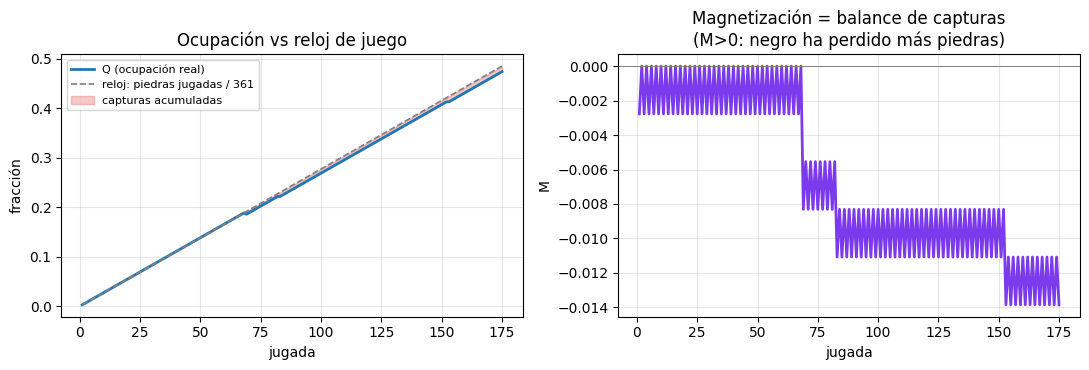

Fracción capturada al final: 0.011 (4 piedras)


In [2]:
# M y la fracción capturada a lo largo de la partida
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(df.index, df['Q'], lw=2, label='Q (ocupación real)')
axes[0].plot(df.index, df['piedras_jugadas'] / 361, lw=1.2, ls='--', color='gray',
             label='reloj: piedras jugadas / 361')
axes[0].fill_between(df.index, df['Q'], df['piedras_jugadas'] / 361,
                     color='#dc2626', alpha=0.25, label='capturas acumuladas')
axes[0].set(xlabel='jugada', ylabel='fracción', title='Ocupación vs reloj de juego')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['M'], lw=2, color='#7c3aed')
axes[1].axhline(0, color='gray', lw=0.7)
axes[1].set(xlabel='jugada', ylabel='M', title='Magnetización = balance de capturas\n(M>0: negro ha perdido más piedras)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Fracción capturada al final: {df['frac_capturada'].iloc[-1]:.3f} "
      f"({df['frac_capturada'].iloc[-1]*361:.0f} piedras)")


## 2. Correlación por escala: separar orden de vacío

Para cada distancia Manhattan $R$ contamos los pares de puntos y los clasificamos. La medida ingenua $\langle s_is_j\rangle$ sobre *todos* los pares confunde dos cosas, porque cualquier par que toque un vacío aporta 0. Por eso separamos:

$$C_{\text{occ}}(R) = \frac{\#(\text{mismo color}) - \#(\text{color opuesto})}{\#(\text{ambos ocupados})} \qquad\in[-1,+1]$$

$$O(R) = \frac{\#(\text{ambos ocupados})}{\#(\text{todos los pares a distancia } R)}$$

**Ejemplo con 4 pares a distancia 1:** (N,N)→+1, (N,B)→−1, (N,vacío)→0, (B,B)→+1. La medida ingenua da $(1-1+0+1)/4 = 0.25$ (diluida); las separadas dan $C_{\text{occ}} = 1/3$ (de las piedras que se ven, predominan amistades) y $O = 3/4$ (densidad).

Lecturas: $C_{\text{occ}}(1) > 0$ → grupos sólidos del mismo color en contacto; $C_{\text{occ}}(1) < 0$ → fase de pelea cuerpo a cuerpo.


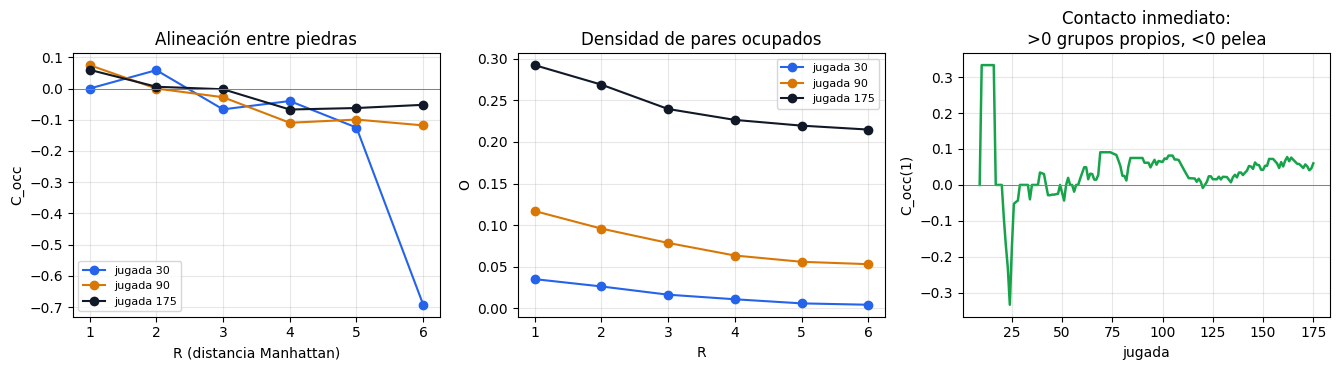

In [3]:
# Perfiles C_occ(R) y O(R) en tres momentos + evolución de C_occ(1)
R_axis = np.arange(1, R_MAX + 1)
momentos = [30, 90, len(moves)]
colores = ['#2563eb', '#d97706', '#111827']

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for t, c in zip(momentos, colores):
    fila = df.loc[t]
    axes[0].plot(R_axis, [fila[f'C_occ_{k}'] for k in R_axis], 'o-', color=c, label=f'jugada {t}')
    axes[1].plot(R_axis, [fila[f'O_{k}'] for k in R_axis], 'o-', color=c, label=f'jugada {t}')
axes[0].axhline(0, color='gray', lw=0.7)
axes[0].set(xlabel='R (distancia Manhattan)', ylabel='C_occ', title='Alineación entre piedras')
axes[1].set(xlabel='R', ylabel='O', title='Densidad de pares ocupados')
for ax in axes[:2]:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[2].plot(df.index, df['C_occ_1'], lw=1.8, color='#16a34a')
axes[2].axhline(0, color='gray', lw=0.7)
axes[2].set(xlabel='jugada', ylabel='C_occ(1)',
            title='Contacto inmediato:\n>0 grupos propios, <0 pelea')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Información mutua: la dependencia completa, en bits

$C_{\text{occ}}$ solo ve la alineación de color entre piedras. La **información mutua** entre el estado de dos puntos a distancia $R$ mide *toda* la dependencia estadística — colores y vacíos incluidos:

$$MI(R) = \sum_{a,b\in\{-1,0,+1\}} p_R(a,b)\,\log_2\frac{p_R(a,b)}{p(a)\,p(b)}$$

donde $p_R(a,b)$ es la frecuencia del par $(s_i=a, s_j=b)$ a distancia $R$. Interpretación: **cuántos bits aprendo sobre un punto al observar otro a distancia $R$**. $MI=0$ ⟺ independencia. Calibración con casos exactos (verificados en las pruebas del módulo): tablero ajedrezado → $MI = 1$ bit exacto (conocer un punto determina el otro); tablero de un solo color → $MI = 0$ (no hay nada que aprender); tablero aleatorio → $MI \approx 0$.

La **entropía condicional** $H(s_j\,|\,s_i) = H_{\text{conjunta}} - H_{\text{marginal}}$ es la incertidumbre que *queda* sobre un punto tras ver el otro.

A diferencia de $C_{\text{occ}}(R)$ (que oscila de signo), $MI(R)$ es positiva y decae con la distancia, así que de su decaimiento extraemos una **longitud de información** $\xi_{\text{info}}$: hasta qué distancia un punto del tablero "sabe" de los demás. (Para correlaciones débiles $MI \sim C^2$, así que $\xi_{\text{info}} \approx \xi_C/2$.)


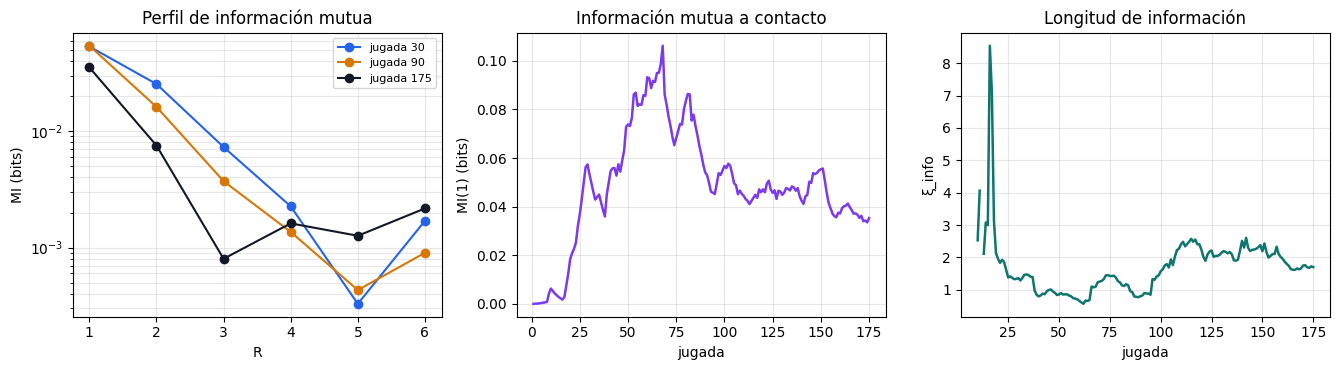

In [4]:
# Perfiles MI(R) (escala log) y evolución de MI(1) y xi_info
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for t, c in zip(momentos, colores):
    fila = df.loc[t]
    axes[0].semilogy(R_axis, [max(fila[f'MI_{k}'], 1e-5) for k in R_axis], 'o-', color=c, label=f'jugada {t}')
axes[0].set(xlabel='R', ylabel='MI (bits)', title='Perfil de información mutua')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which='both')

axes[1].plot(df.index, df['MI_1'], lw=1.8, color='#7c3aed')
axes[1].set(xlabel='jugada', ylabel='MI(1) (bits)', title='Información mutua a contacto')
axes[1].grid(alpha=0.3)

axes[2].plot(df.index, df['xi_info'], lw=1.8, color='#0f766e')
axes[2].set(xlabel='jugada', ylabel='ξ_info', title='Longitud de información')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. β estructural: ¿qué tan "Boltzmann" se ve el tablero?

La pregunta: *si este tablero hubiera sido generado por un modelo de Boltzmann con el Hamiltoniano estructural par*

$$H_R = -J \sum_{d(i,j)\le R} w_d\, s_i s_j + D \sum_i s_i^2, \qquad w_d = 1/d,$$

*¿qué parámetros lo explicarían mejor?* El método (pseudoverosimilitud de Besag, estándar en estadística de modelos de Ising): congelar los vecinos de cada punto, escribir la probabilidad condicional del centro

$$P(s_i = s \mid \text{vecinos}) \propto \exp\!\big(\beta J\, s\, F_i - \beta D\, s^2\big), \qquad F_i = \sum_R w_R \sum_{j\in S_R(i)} s_j,$$

y maximizar la verosimilitud del tablero observado. El campo $F_i$ es exactamente una convolución de anillos — el cálculo cuesta milisegundos.

Tres letras chicas: (1) solo los **productos** $\beta J$ y $\beta D$ son identificables (fijamos $J=1$); (2) al inicio casi todo es vacío y $\widehat{\beta J}$ sale ruidoso — no interpretar las primeras ~30 jugadas; (3) es un **descriptor**, no una temperatura física. Calibración verificada: tablero de un color → $\beta J \gg 0$; ajedrezado → $\beta J \ll 0$; aleatorio → $\beta J \approx 0$.

Lecturas: $\beta J$ alto = organización ferro (grupos cohesionados); $\beta J < 0$ = organización antiferro (colores entreverados: pelea); $\beta D$ = costo efectivo de ocupación (baja conforme el tablero se llena).


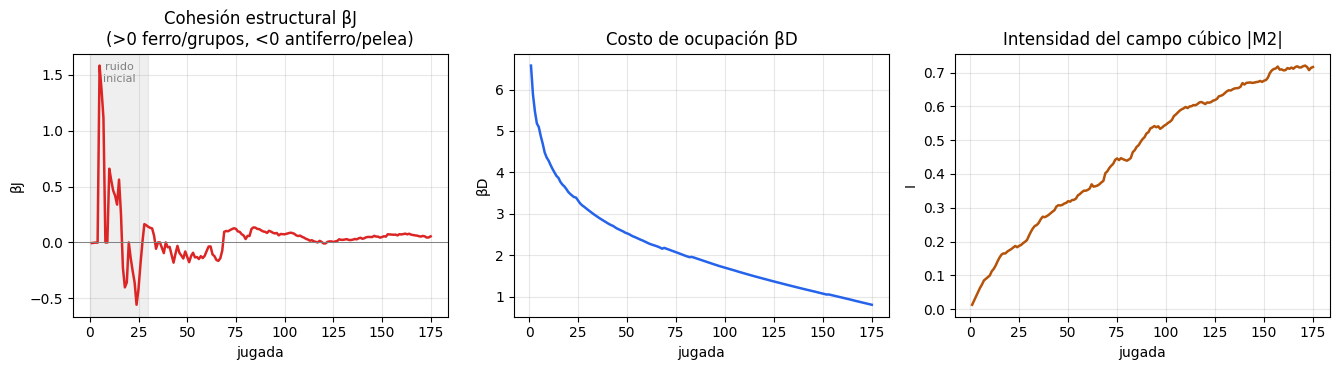

In [5]:
# ¿La partida se enfría? betaJ, betaD y la pseudoverosimilitud
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axes[0].plot(df.index, df['betaJ'], lw=1.8, color='#dc2626')
axes[0].axhline(0, color='gray', lw=0.7)
axes[0].axvspan(0, 30, color='gray', alpha=0.12)
axes[0].text(15, axes[0].get_ylim()[1]*0.85, 'ruido\ninicial', fontsize=8, ha='center', color='gray')
axes[0].set(xlabel='jugada', ylabel='βJ', title='Cohesión estructural βJ\n(>0 ferro/grupos, <0 antiferro/pelea)')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['betaD'], lw=1.8, color='#2563eb')
axes[1].set(xlabel='jugada', ylabel='βD', title='Costo de ocupación βD')
axes[1].grid(alpha=0.3)

axes[2].plot(df.index, df['I_cubico'], lw=1.8, color='#b45309')
axes[2].set(xlabel='jugada', ylabel='I', title='Intensidad del campo cúbico |M2|')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [6]:
# Resumen por fases de la partida
fases = pd.cut(df.index, bins=[0, 40, 120, len(moves)],
               labels=['apertura (1-40)', 'medio juego (41-120)', 'final (121+)'])
resumen = df.groupby(fases, observed=True)[['Q', 'M', 'C_occ_1', 'MI_1', 'xi_info',
                             'betaJ', 'betaD', 'I_cubico']].mean().round(3)
display(resumen)


,Q,M,C_occ_1,MI_1,xi_info,betaJ,betaD,I_cubico
apertura (1-40),0.057,-0.001,0.038,0.023,2.183,0.123,3.782,0.166
medio juego (41-120),0.218,-0.006,0.039,0.066,1.305,0.008,2.014,0.457
final (121+),0.401,-0.011,0.043,0.044,2.032,0.045,1.103,0.677


## 5. Lectura de los resultados

Con una sola partida no se concluye nada estadístico, pero el experimento muestra que el vector macro **se mueve y distingue fases**:

- $Q$ marcha con el reloj y la brecha con él acumula las capturas; $M$ registra cada captura como un escalón.
- $C_{\text{occ}}(1)$ y $MI(1)$ cuentan la historia estructural: la alineación de contacto sube cuando se consolidan grupos y baja (o se hace negativa) en las fases de pelea.
- $\beta J$ es la versión "termodinámica" de lo mismo: su señal debe correlacionar con $C_{\text{occ}}(1)$ pero pesando todas las escalas hasta $R$, y $\beta D$ decae conforme ocupar el tablero deja de ser "costoso" — el llenado del tablero leído como enfriamiento del grado de libertad de ocupación.

**Hipótesis a probar con la biblioteca completa de SGF** (siguiente iteración): (1) ¿$\beta J(t)$ crece sistemáticamente hacia el final — "la partida se enfría"? (2) ¿el mínimo de $C_{\text{occ}}(1)$ localiza las peleas grandes? (3) ¿los perfiles $MI(R)$ distinguen estilos de juego (territorial vs influencia)?

## Siguiente paso: integración al motor de visualización

`macro_trajectory` devuelve un `DataFrame` indexado por jugada — el formato listo para que el `GameNavigator` muestre un panel "Macro" con estas series y un cursor sincronizado con la jugada actual. La celda siguiente guarda la trayectoria para reutilizarla.


In [7]:
# Guardar la trayectoria para reuso (visualización, comparación entre partidas)
out_dir = root / 'results'
out_dir.mkdir(exist_ok=True)
out_csv = out_dir / f'macro_{Path(SGF_FILE).stem}.csv'
df.to_csv(out_csv)
print(f'Trayectoria macro guardada en {out_csv} ({df.shape[0]} filas x {df.shape[1]} columnas)')


Trayectoria macro guardada en C:\Users\ometi\Documents\IA\Github\Ising-go\Proyect-Quantum-Go\results\macro_3a3d-gokifu-20210609-Peng_Liyao-Xia_Chenkun.csv (175 filas x 35 columnas)
